In [20]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload
import pickle as pkl
from datetime import datetime

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

<module 'src.sat_metropolis.models' from '/home/kristoffer/ITU/6_semester/linux_bachelor_project/sat-metropolis-businessnisser/src/sat_metropolis/models.py'>

In [21]:
# Taken from (Simson Garfinkel, John M. Abowd, Christian Martindale. Understanding Database Reconstruction Attacks on Public Data. Communications of the ACM, March 2019, Vol. 62 No. 3, Pages 46-53. DOI: 10.1145/3287287)

# Assumption, all bit-vectors are of the same size
num_bits = 8
num_vars = 5*2 # (age, gender)
var_list = [BitVec(f'x{i}',num_bits) for i in range(num_vars)] # 0-4 age vars, 5-9 sex vars
x = var_list
g = Goal()
sat.add_bool_vars_to_goal(g, var_list)
g.add(sat.addition_does_not_overflow([x[0], x[1], x[2], x[3], x[4]]))
g.add(sat.addition_does_not_overflow([x[5], x[6], x[7], x[8], x[9]]))
for i in range(5):
    g.add(sat.multi_does_not_overflow([x[i],x[i+5]])) # this is in case of multiplication

# these are binary (obviously only for the purpose of the example)
# FEMALE = 0
# MALE = 1
for i in range(5,10):
    g.add(ULE(0,x[i]))
    g.add(ULE(x[i],1))


# establish an order to set the median
g.add(ULE(0,x[0]))
g.add(ULE(x[0],x[1]))
g.add(ULE(x[1],x[2]))
g.add(ULE(x[2],x[3]))
g.add(ULE(x[3],x[4]))
g.add(ULE(x[4],125))

g.add(x[2] == 30) # median

g.add(x[0] + x[1] + x[2] + x[3] + x[4] == 38*5) # average age

g.add(x[5] + x[6] + x[7] + x[8] + x[9] == 3) # only 3 males

g.add(x[0]*x[5] + x[1]*x[6] + x[2]*x[7] + x[3]*x[8] + x[4]*x[9] == 44*3) # average age of males

# NOTE: we might need to set an overflow constraint for the last sum.


In [17]:
# trace = sat.get_conditional_incremental_samples_sat_pyunigen_problem_cached(
#     z3_problem=g,
#     num_vars=num_vars,
#     num_bits=num_bits,
#     D=3,
#     num_samples=1,
#     num_iterations=1000,
#     sanity_check_problem=True,
#     print_z3_model=False
# )

variables_number: {1: k!33019, 2: x00, 3: k!33020, 4: x01, 5: k!33021, 6: x02, 7: k!33022, 8: x03, 9: k!33023, 10: x04, 11: k!33024, 12: x05, 13: k!33025, 14: x06, 15: k!33026, 16: x07, 17: k!33027, 18: x10, 19: k!33028, 20: x11, 21: k!33029, 22: x12, 23: k!33030, 24: x13, 25: k!33031, 26: x14, 27: k!33032, 28: x15, 29: k!33033, 30: x16, 31: k!33034, 32: x17, 33: k!33035, 34: x20, 35: k!33036, 36: x21, 37: k!33037, 38: x22, 39: k!33038, 40: x23, 41: k!33039, 42: x24, 43: k!33040, 44: x25, 45: k!33041, 46: x26, 47: k!33042, 48: x27, 49: k!33043, 50: x30, 51: k!33044, 52: x31, 53: k!33045, 54: x32, 55: k!33046, 56: x33, 57: k!33047, 58: x34, 59: k!33048, 60: x35, 61: k!33049, 62: x36, 63: k!33050, 64: x37, 65: k!33051, 66: x40, 67: k!33052, 68: x41, 69: k!33053, 70: x42, 71: k!33054, 72: x43, 73: k!33055, 74: x44, 75: k!33056, 76: x45, 77: k!33057, 78: x46, 79: k!33058, 80: x47, 81: k!33059, 82: x50, 83: k!33060, 84: x51, 85: k!33061, 86: x52, 87: k!33062, 88: x53, 89: k!33063, 90: x54, 

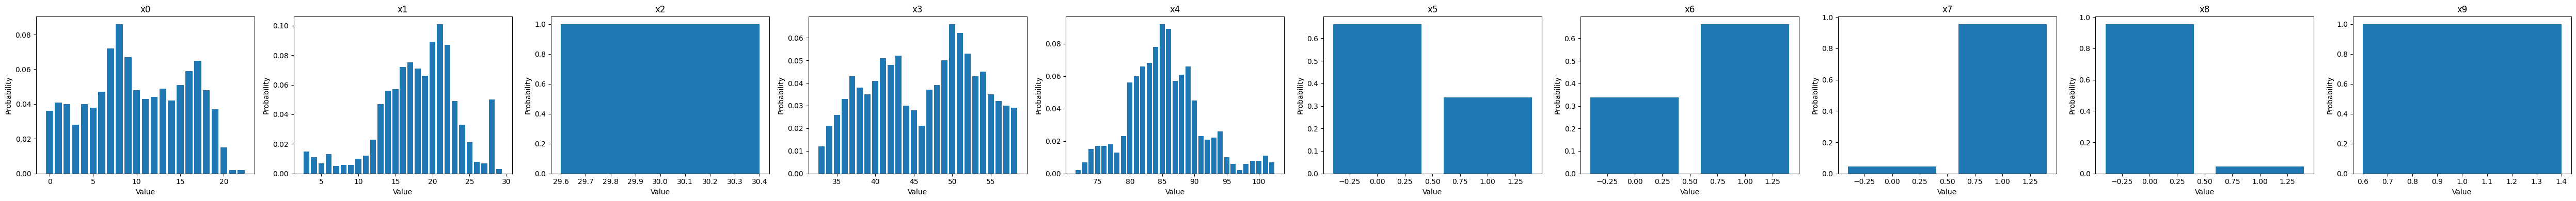

variables_number: {1: k!34591, 2: x00, 3: k!34592, 4: x01, 5: k!34593, 6: x02, 7: k!34594, 8: x03, 9: k!34595, 10: x04, 11: k!34596, 12: x05, 13: k!34597, 14: x06, 15: k!34598, 16: x07, 17: k!34599, 18: x10, 19: k!34600, 20: x11, 21: k!34601, 22: x12, 23: k!34602, 24: x13, 25: k!34603, 26: x14, 27: k!34604, 28: x15, 29: k!34605, 30: x16, 31: k!34606, 32: x17, 33: k!34607, 34: x20, 35: k!34608, 36: x21, 37: k!34609, 38: x22, 39: k!34610, 40: x23, 41: k!34611, 42: x24, 43: k!34612, 44: x25, 45: k!34613, 46: x26, 47: k!34614, 48: x27, 49: k!34615, 50: x30, 51: k!34616, 52: x31, 53: k!34617, 54: x32, 55: k!34618, 56: x33, 57: k!34619, 58: x34, 59: k!34620, 60: x35, 61: k!34621, 62: x36, 63: k!34622, 64: x37, 65: k!34623, 66: x40, 67: k!34624, 68: x41, 69: k!34625, 70: x42, 71: k!34626, 72: x43, 73: k!34627, 74: x44, 75: k!34628, 76: x45, 77: k!34629, 78: x46, 79: k!34630, 80: x47, 81: k!34631, 82: x50, 83: k!34632, 84: x51, 85: k!34633, 86: x52, 87: k!34634, 88: x53, 89: k!34635, 90: x54, 

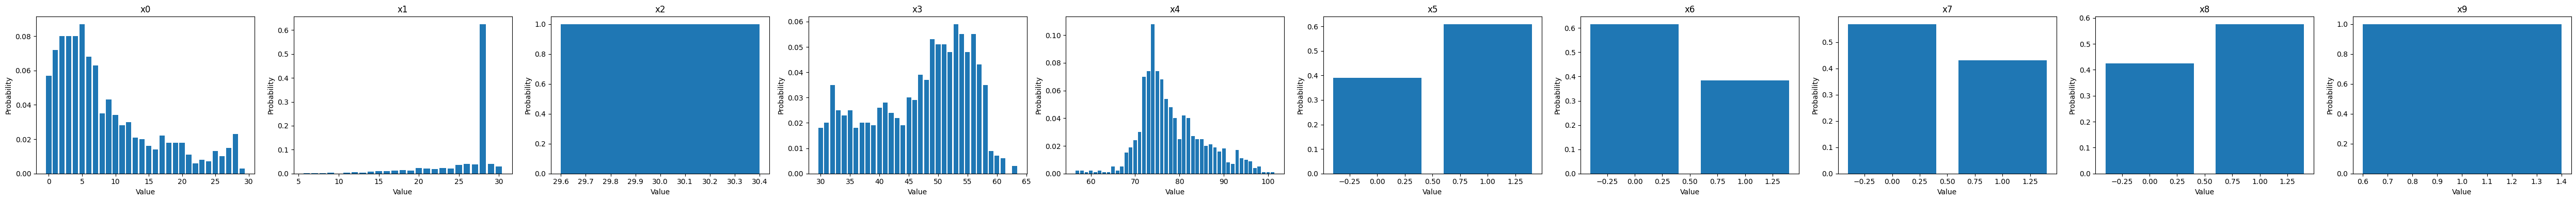

variables_number: {1: k!36137, 2: x00, 3: k!36138, 4: x01, 5: k!36139, 6: x02, 7: k!36140, 8: x03, 9: k!36141, 10: x04, 11: k!36142, 12: x05, 13: k!36143, 14: x06, 15: k!36144, 16: x07, 17: k!36145, 18: x10, 19: k!36146, 20: x11, 21: k!36147, 22: x12, 23: k!36148, 24: x13, 25: k!36149, 26: x14, 27: k!36150, 28: x15, 29: k!36151, 30: x16, 31: k!36152, 32: x17, 33: k!36153, 34: x20, 35: k!36154, 36: x21, 37: k!36155, 38: x22, 39: k!36156, 40: x23, 41: k!36157, 42: x24, 43: k!36158, 44: x25, 45: k!36159, 46: x26, 47: k!36160, 48: x27, 49: k!36161, 50: x30, 51: k!36162, 52: x31, 53: k!36163, 54: x32, 55: k!36164, 56: x33, 57: k!36165, 58: x34, 59: k!36166, 60: x35, 61: k!36167, 62: x36, 63: k!36168, 64: x37, 65: k!36169, 66: x40, 67: k!36170, 68: x41, 69: k!36171, 70: x42, 71: k!36172, 72: x43, 73: k!36173, 74: x44, 75: k!36174, 76: x45, 77: k!36175, 78: x46, 79: k!36176, 80: x47, 81: k!36177, 82: x50, 83: k!36178, 84: x51, 85: k!36179, 86: x52, 87: k!36180, 88: x53, 89: k!36181, 90: x54, 

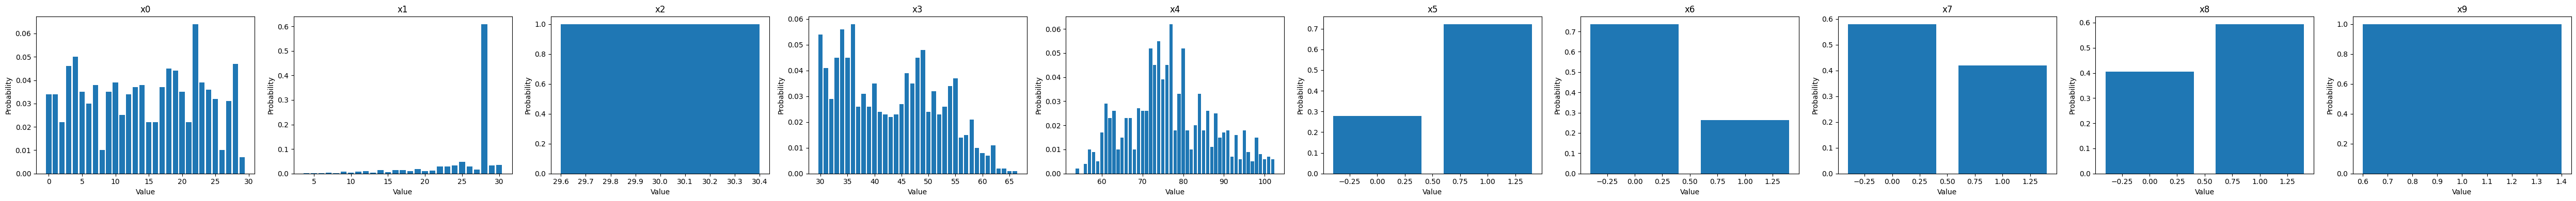

variables_number: {1: k!37708, 2: x00, 3: k!37709, 4: x01, 5: k!37710, 6: x02, 7: k!37711, 8: x03, 9: k!37712, 10: x04, 11: k!37713, 12: x05, 13: k!37714, 14: x06, 15: k!37715, 16: x07, 17: k!37716, 18: x10, 19: k!37717, 20: x11, 21: k!37718, 22: x12, 23: k!37719, 24: x13, 25: k!37720, 26: x14, 27: k!37721, 28: x15, 29: k!37722, 30: x16, 31: k!37723, 32: x17, 33: k!37724, 34: x20, 35: k!37725, 36: x21, 37: k!37726, 38: x22, 39: k!37727, 40: x23, 41: k!37728, 42: x24, 43: k!37729, 44: x25, 45: k!37730, 46: x26, 47: k!37731, 48: x27, 49: k!37732, 50: x30, 51: k!37733, 52: x31, 53: k!37734, 54: x32, 55: k!37735, 56: x33, 57: k!37736, 58: x34, 59: k!37737, 60: x35, 61: k!37738, 62: x36, 63: k!37739, 64: x37, 65: k!37740, 66: x40, 67: k!37741, 68: x41, 69: k!37742, 70: x42, 71: k!37743, 72: x43, 73: k!37744, 74: x44, 75: k!37745, 76: x45, 77: k!37746, 78: x46, 79: k!37747, 80: x47, 81: k!37748, 82: x50, 83: k!37749, 84: x51, 85: k!37750, 86: x52, 87: k!37751, 88: x53, 89: k!37752, 90: x54, 

In [ ]:
ds = [1,3,5,10,20]
samples = 1000
current_time = datetime.now()
formatted = (
    f"y{current_time.year}"
    f"m{current_time.month:02d}"
    f"d{current_time.day:02d}"
    f"h{current_time.hour:02d}"
    f"m{current_time.minute:02d}"
    f"s{current_time.second:02d}"
)
for k in range(3):
    for i in range(len(ds)):
        trace = mcmc.sample_mh_trace_from_z3_model(
            backend='inc_pyunigen_new',
            z3_problem=g,
            D=ds[i],
            num_vars=num_vars,
            num_bits=num_bits,
            parallel_samples=1,
            time_tracking= True,
            num_samples=samples,
            print_z3_model=False
        )
        
        az.to_netcdf(trace[0], f'{project_root}/experiments/traces/d_tests/trace_db_cacm_{samples}_inc_pyunigen_new_{k+1}_d{ds[i]}_{formatted}.nc')
        with open(f'{project_root}/experiments/traces/d_tests/trace_db_cacm_{samples}_inc_pyunigen_new_{k+1}_d{ds[i]}_with_timetracking_{formatted}.pkl', "wb") as f:
            pkl.dump(trace[1], f)
        
        


In [10]:
# trace = mcmc.sample_mh_trace_from_z3_model(backend='unigen',
#                                            z3_problem=g,
#                                            num_vars=num_vars,
#                                            num_bits=num_bits,
#                                            timeout_sampler=3600,
#                                            num_samples=5000,
#                                            num_chains=10)

In [19]:
trace

Inference data with groups:
	> posterior

In [20]:
from collections import Counter
import matplotlib.pyplot as plt
import math

def plot_distributions(samples):
    keys = list(samples[0].keys())
    n = len(keys)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, key in zip(axes, keys):
        vals = [d[key] for d in samples]
        c = Counter(vals)

        xs = sorted(c.keys())
        total = sum(c.values())
        ys = [c[x] / total for x in xs]

        ax.bar(xs, ys)
        ax.set_title(key)
        ax.set_xlabel("Value")
        ax.set_ylabel("Probability")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

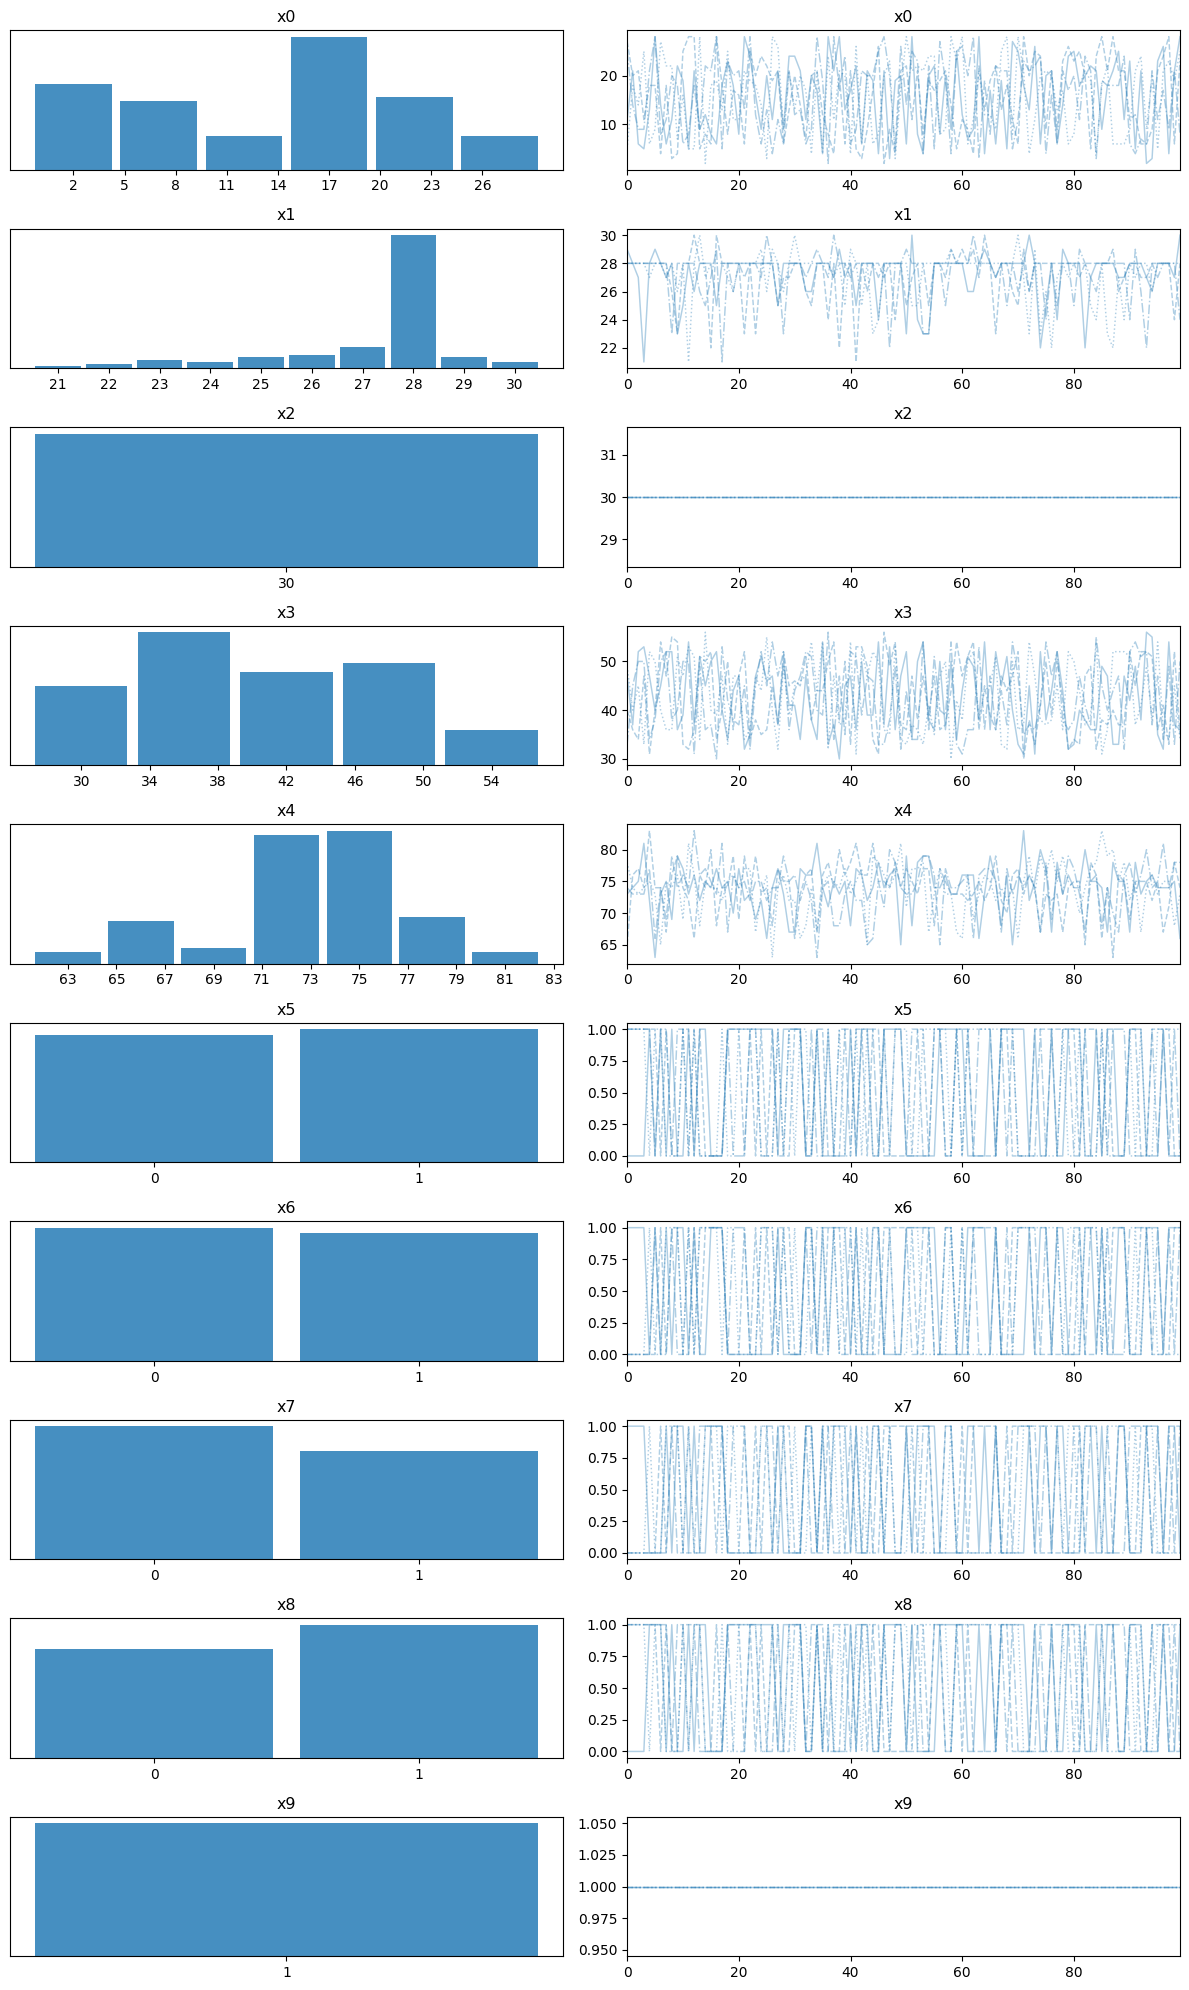

In [23]:
# Trace plot
az.plot_trace(trace);
plt.savefig('unigen_trace_plot.png', dpi=15);

In [14]:
# Diagnosis
az.summary(trace)

/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,15.88,7.775,4.0,28.0,0.347,0.163,487.0,400.0,1.00
x1,27.23,1.751,22.0,29.0,0.086,0.098,496.0,376.0,1.00
x2,30.00,0.000,30.0,30.0,0.000,NaN,400.0,400.0,NaN
x3,42.93,7.419,32.0,54.0,0.332,0.138,490.0,340.0,0.99
x4,73.96,3.914,65.0,80.0,0.194,0.123,342.0,362.0,1.00
x5,0.51,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x6,0.49,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x7,0.45,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x8,0.55,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x9,1.00,0.000,1.0,1.0,0.000,NaN,400.0,400.0,NaN


In [15]:
utils.save_trace(trace, f'db_cacm_SAT_inc_pyunigen_{num_vars}_{num_bits}.nc')

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) ANALYTICAL SOLUTION
# ============================================================

# list all ages with required median and average age
avg_sat = [
    (x0, x1, 30, x3, x4)
    for x0 in range(31)
    for x1 in range(31)
    for x3 in range(30, 126)
    for x4 in range(30, 126)
    if x0 + x1 + 30 + x3 + x4 == 38 * 5
    and x0 <= x1 <= 30 <= x3 <= x4
]

# list all genders with exactly 3 males
g_sat = [
    (g0, g1, g2, g3, g4)
    for g0 in range(2)
    for g1 in range(2)
    for g2 in range(2)
    for g3 in range(2)
    for g4 in range(2)
    if g0 + g1 + g2 + g3 + g4 == 3
]

# keep only entries with the required average for males
sat_models = [
    ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4))
    for (x0, x1, x2, x3, x4) in avg_sat
    for (g0, g1, g2, g3, g4) in g_sat
    if x0 * g0 + x1 * g1 + x2 * g2 + x3 * g3 + x4 * g4 == 44 * 3
]

# prior on each variable type
p_x01 = lambda x: 1 / 31
p_x2 = lambda x: 1
p_x34 = lambda x: 1 / 96
p_g = lambda x: 1 / 2

# compute unnormalized posterior probabilities
unnormalized_probs = np.array([
    p_x01(x0) * p_x01(x1) * p_x2(x2) * p_x34(x3) * p_x34(x4)
    * p_g(g0) * p_g(g1) * p_g(g2) * p_g(g3) * p_g(g4)
    for ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)) in sat_models
])

# compute total probability mass (normalizing factor)
total_prob = unnormalized_probs.sum()

# normalized probabilities
normalized_probs = unnormalized_probs / total_prob

# put everything in a dataframe
d = {
    'x0': [], 'x1': [], 'x2': [], 'x3': [], 'x4': [],
    'g0': [], 'g1': [], 'g2': [], 'g3': [], 'g4': [],
    'p': []
}

for (((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)), p) in zip(sat_models, normalized_probs):
    d['x0'].append(x0)
    d['x1'].append(x1)
    d['x2'].append(x2)
    d['x3'].append(x3)
    d['x4'].append(x4)
    d['g0'].append(g0)
    d['g1'].append(g1)
    d['g2'].append(g2)
    d['g3'].append(g3)
    d['g4'].append(g4)
    d['p'].append(p)

df = pd.DataFrame(d)

# exact analytical marginal probability
def p_var(var_name, outcome):
    return df.loc[df[var_name] == outcome, 'p'].sum()

# ============================================================
# 2) SINGLE TRACE VS ANALYTICAL SOLUTION
# ============================================================
# Assumes:
#   - `trace` is one ArviZ InferenceData object
#   - trace.posterior contains x0, x1, ..., x9
#
# Mapping:
#   x0..x4  -> exact vars x0..x4
#   x5..x9  -> exact vars g0..g4

def p_est_single(trace, var_name, outcome):
    vals = trace.posterior[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    # support of each variable
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    # map sampled variable name to analytical variable name
    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    # mean absolute difference over the full support
    err = np.mean([
        abs(p_est_single(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)


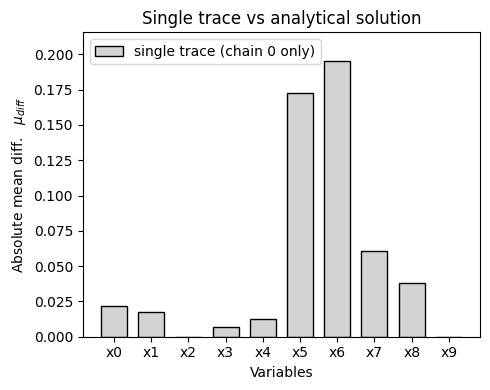

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# empirical probability from ONE CHAIN ONLY (to match your paper code)
def p_est_single_chain(trace, var_name, outcome):
    vals = trace.posterior.sel(chain=0)[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    err = np.mean([
        abs(p_est_single_chain(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

xpos = np.arange(len(df_single_trace))
ax.bar(
    xpos,
    df_single_trace['err_mean_mean'].values,
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace (chain 0 only)'
)

ax.set_xticks(xpos, df_single_trace['var_name'].values, rotation=0)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)

plt.tight_layout()
plt.show()

  var_name  err_mean_mean
0       x0       0.021864
1       x1       0.017329
2       x2       0.000000
3       x3       0.006994
4       x4       0.012255
5       x5       0.172440
6       x6       0.195573
7       x7       0.061041
8       x8       0.037907
9       x9       0.000000


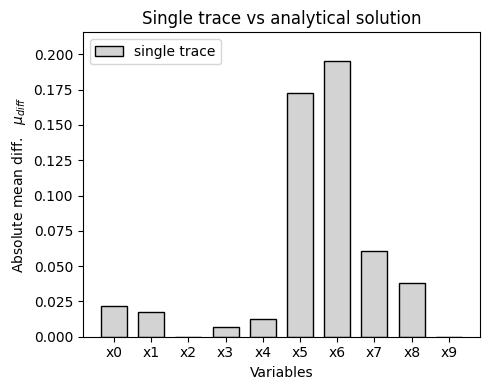

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def p_est_original_style(trace_chain0, var_name, outcome):
    return np.mean(trace_chain0[var_name] == outcome).item()

variables = ['x0','x1','x2','x3','x4','x5','x6','x7','x8','x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

trace_chain0 = trace.posterior.sel(chain=0)

for x in variables:
    ran = range(30, 31)
    if x in ['x0', 'x1']:
        ran = range(31)
    elif x in ['x3', 'x4']:
        ran = range(30, 126)
    elif x in ['x5', 'x6', 'x7', 'x8', 'x9']:
        ran = range(2)

    outcomes = ran
    x_conv = x if x in ['x0','x1','x2','x3','x4'] else 'g' + str(int(x[1]) - 5)

    err_outcome_mean = np.mean([
        np.abs(p_est_original_style(trace_chain0, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err_outcome_mean)

df_single_trace = pd.DataFrame(data_single_trace)
print(df_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(
    df_single_trace['var_name'],
    df_single_trace['err_mean_mean'],
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace'
)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)
plt.tight_layout()
plt.show()